In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Etape 2 : Pre-processing et feature engineering

In [146]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')
target = df_ventes.prix_bien

Attendue de cette étape :

* Suite aux constats établis lors de l’étape précédente, vous devrez nettoyer votre jeu de données et effectuer les étapes de pre-processing.
* Si besoin, il faudra transformer et/ou ajouter des features et enrichir votre jeu de données.
* L’objectif à la fin de cette étape est d’avoir un dataset prêt pour effectuer des analyses approfondies et/ou une modélisation à l’aide de Machine (et Deep) Learning.

**Pour la suite du projet, nous nous consentrerons sur les données de ventes (ech_annonces_ventes_68.csv)**

## Tâches pour Matthieu
* Rajouter les données géographiques
* Gestion des outliers

### Nettoyage des variables numériques (outliers)

**Nous souhaitons identifier les outiliers dans notre jeu de données afin de les retirer pour améliorer les prédictions de nos futurs modèles.**

In [147]:
numeric_cols = df_ventes.select_dtypes(include=['number']).columns.tolist()

numeric_cols

['etage',
 'surface',
 'surface_terrain',
 'nb_pieces',
 'prix_bien',
 'prix_maison',
 'prix_terrain',
 'mensualiteFinance',
 'balcon',
 'eau',
 'bain',
 'dpeC',
 'mapCoordonneesLatitude',
 'mapCoordonneesLongitude',
 'nb_etages',
 'places_parking',
 'annee_construction',
 'nb_toilettes',
 'nb_terraces',
 'surface_balcon',
 'nb_logements_copro',
 'charges_copro',
 'duree_int',
 'INSEE_COM',
 'IRIS',
 'CODE_IRIS',
 'GRD_QUART',
 'UU2010',
 'REG',
 'DEP',
 'loyer_m2_median_n6',
 'nb_log_n6',
 'taux_rendement_n6',
 'loyer_m2_median_n7',
 'nb_log_n7',
 'taux_rendement_n7',
 'prix_m2_vente']

#### Supression des outiliers en utilisant les quartiles Q1, Q3 et l'espace inter quartile

Pour chaque variable numérique, non traité dans la section précédente, nous allons enlever les echantillons où la valeur est < à Q1 - IQR ou > Q3 + IQR.
* Q1 : 25% des observations <= à cette valeur.
* Q3 : 75% des observations <= à cette valeur.
* IQR = Q3 - Q1.

In [148]:
df_ventes_clean = df_ventes

for col in numeric_cols:
    q1 = np.abs(df_ventes[col].quantile(0.25))
    q3 = np.abs(df_ventes[col].quantile(0.75))
    iqr = q3 - q1
    lower = q1 - iqr
    upper = q3 + iqr

    df_ventes_clean = df_ventes[(df_ventes[col] >= lower) & (df_ventes[col] <= upper)]

nb_rows_avant = df_ventes.shape[0]
nb_rows_apres = df_ventes_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("dataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

dataframe initial :  27737  rows.
dataframe nettoyé avec iqr :  26924  rows.
Proportion conservé :  97.069 %
Nombre d'observations supprimées :  813


Nous avons ainsi éliminé environs 3% de nos observations, soit 813 outliers qui allaient perturber nos prédictions.

### Pre-processing des données géographiques

**Dans notre jeu de données, nous disposons des coordonnées GPS des logements :**

* mapCoordonneesLongitude
* mapCoordonneesLatitude

In [149]:
df_ventes_clean[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']].head(10)

,mapCoordonneesLatitude,mapCoordonneesLongitude
idannonce,,
hektor-robischung-2862,47.55424,7.34766
apimo-82452515,48.17073,7.10498
immo-facile-52471952,48.16989,7.13037
immo-facile-52477215,48.17061,7.11870
ag681088-383601401,47.88536,7.19668
ag681104-381823822,47.54152,7.28713
hektor-robischung-2873,47.54331,7.29446
ag681158-383546936,47.91827,7.13488
ag751938-380728492,47.74310,7.33110


In [150]:
df_ventes_clean[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']].describe()

,mapCoordonneesLatitude,mapCoordonneesLongitude
count,26924.000000,26924.000000
mean,47.808026,7.335500
std,0.180726,0.129553
min,47.427000,6.859940
25%,47.680395,7.272005
50%,47.761720,7.338930
75%,47.935862,7.400240
max,48.303780,7.616300


Nous avons des valeurs très rapprochées, dû à la nature de notre jeu de données se focalisant sur le département 68.

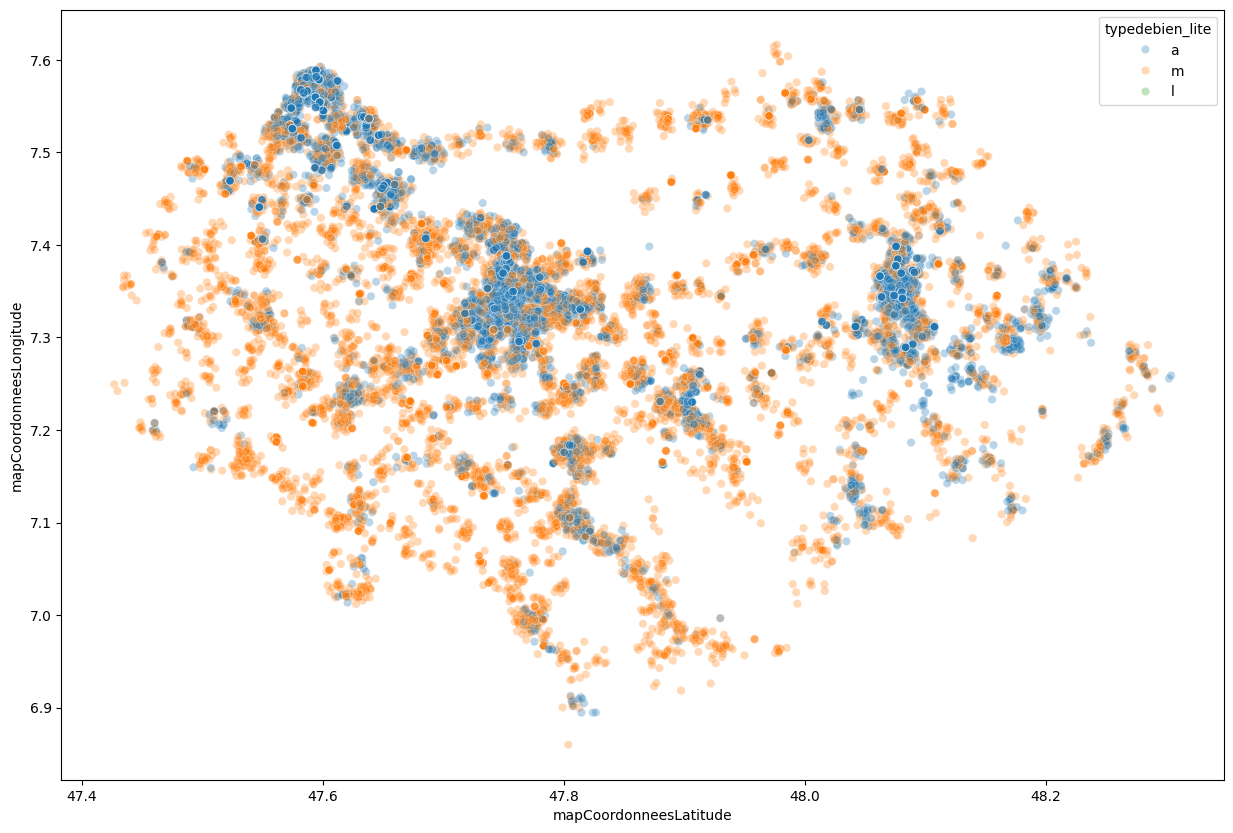

In [151]:
plt.figure(figsize=(15,10))
ax = sns.scatterplot(data=df_ventes_clean, x='mapCoordonneesLatitude', y='mapCoordonneesLongitude', hue='typedebien_lite', alpha=0.3)

Avec un simple scatterplot, on observe déjà certaines concentrations d'appartements. Il s'agit très certainement de zones urbaines.

Carte des appartements :

In [152]:
import folium
from folium.plugins import MarkerCluster, HeatMap, FastMarkerCluster

df_ventes_appartement = df_ventes_clean[df_ventes_clean['typedebien_lite'] == 'a']

vente = [df_ventes_appartement['mapCoordonneesLatitude'].mean(), df_ventes_appartement['mapCoordonneesLongitude'].mean()]

min_lat = df_ventes_appartement['mapCoordonneesLatitude'].min()
max_lat = df_ventes_appartement['mapCoordonneesLatitude'].max()
min_lon = df_ventes_appartement['mapCoordonneesLongitude'].min()
max_lon = df_ventes_appartement['mapCoordonneesLongitude'].max()

# Créer la carte
m = folium.Map(
    location=vente,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# MarkerClusters directement ajoutés à la carte
marker_cluster = FastMarkerCluster(data=df_ventes_appartement[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']],).add_to(m)

HeatMap(df_ventes_appartement[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']], min_opacity=0.05).add_to(m)

m

Carte des maisons :

In [153]:
import folium
from folium.plugins import MarkerCluster, HeatMap, FastMarkerCluster

df_ventes_maison = df_ventes_clean[df_ventes_clean['typedebien_lite'] == 'm']

vente = [df_ventes_maison['mapCoordonneesLatitude'].mean(), df_ventes_maison['mapCoordonneesLongitude'].mean()]

min_lat = df_ventes_maison['mapCoordonneesLatitude'].min()
max_lat = df_ventes_maison['mapCoordonneesLatitude'].max()
min_lon = df_ventes_maison['mapCoordonneesLongitude'].min()
max_lon = df_ventes_maison['mapCoordonneesLongitude'].max()

# Créer la carte
m = folium.Map(
    location=vente,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# MarkerClusters directement ajoutés à la carte
marker_cluster = FastMarkerCluster(data=df_ventes_maison[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']],).add_to(m)

HeatMap(df_ventes_maison[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']], min_opacity=0.05, blur=0).add_to(m)

m

#### StandardScaler sur mapCoordonneesLatitude & mapCoordonneesLongitude

**Pour faciliter l'entrainement sur les champs mapCoordonneesLatitude et mapCoordonneesLongitude qui ont une distribution très faible, nous pouvons normaliser les données.**

In [154]:
scaler_latitude = StandardScaler()
df_ventes_clean['Latitude_scaled'] = scaler_latitude.fit_transform(df_ventes_clean[['mapCoordonneesLatitude']])

scaler_longitude = StandardScaler()
df_ventes_clean['Longitude_scaled'] = scaler_longitude.fit_transform(df_ventes_clean[['mapCoordonneesLongitude']])

C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_4312\2445677542.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ventes_clean['Latitude_scaled'] = scaler_latitude.fit_transform(df_ventes_clean[['mapCoordonneesLatitude']])
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_4312\2445677542.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ventes_clean['Longitude_scaled'] = scaler_longitude.fit_transform(df_ventes_clean[['mapCoordonneesLongitude']])


In [155]:
df_ventes_clean[['mapCoordonneesLatitude', 'Latitude_scaled', 'mapCoordonneesLongitude', 'Longitude_scaled']].head(10)

,mapCoordonneesLatitude,Latitude_scaled,mapCoordonneesLongitude,Longitude_scaled
idannonce,,,,
hektor-robischung-2862,47.55424,-1.404288,7.34766,0.093864
apimo-82452515,48.17073,2.006969,7.10498,-1.779374
immo-facile-52471952,48.16989,2.002321,7.13037,-1.583390
immo-facile-52477215,48.17061,2.006305,7.11870,-1.673470
ag681088-383601401,47.88536,0.427916,7.19668,-1.071546
ag681104-381823822,47.54152,-1.474672,7.28713,-0.373365
hektor-robischung-2873,47.54331,-1.464767,7.29446,-0.316785
ag681158-383546936,47.91827,0.610019,7.13488,-1.548577
ag751938-380728492,47.74310,-0.359259,7.33110,-0.033962


In [156]:
df_ventes_clean[['mapCoordonneesLatitude', 'Latitude_scaled', 'mapCoordonneesLongitude', 'Longitude_scaled']].describe()

,mapCoordonneesLatitude,Latitude_scaled,mapCoordonneesLongitude,Longitude_scaled
count,26924.000000,2.692400e+04,26924.000000,2.692400e+04
mean,47.808026,1.454232e-14,7.335500,-7.700801e-15
std,0.180726,1.000019e+00,0.129553,1.000019e+00
min,47.427000,-2.108351e+00,6.859940,-3.670829e+00
25%,47.680395,-7.062274e-01,7.272005,-4.901146e-01
50%,47.761720,-2.562275e-01,7.338930,2.647703e-02
75%,47.935862,7.073644e-01,7.400240,4.997267e-01
max,48.303780,2.743182e+00,7.616300,2.167486e+00


#### Target Encoding sur INSEE_COM

On regarde maintenant la variable INSEE_COM (code de commune INSEE) :

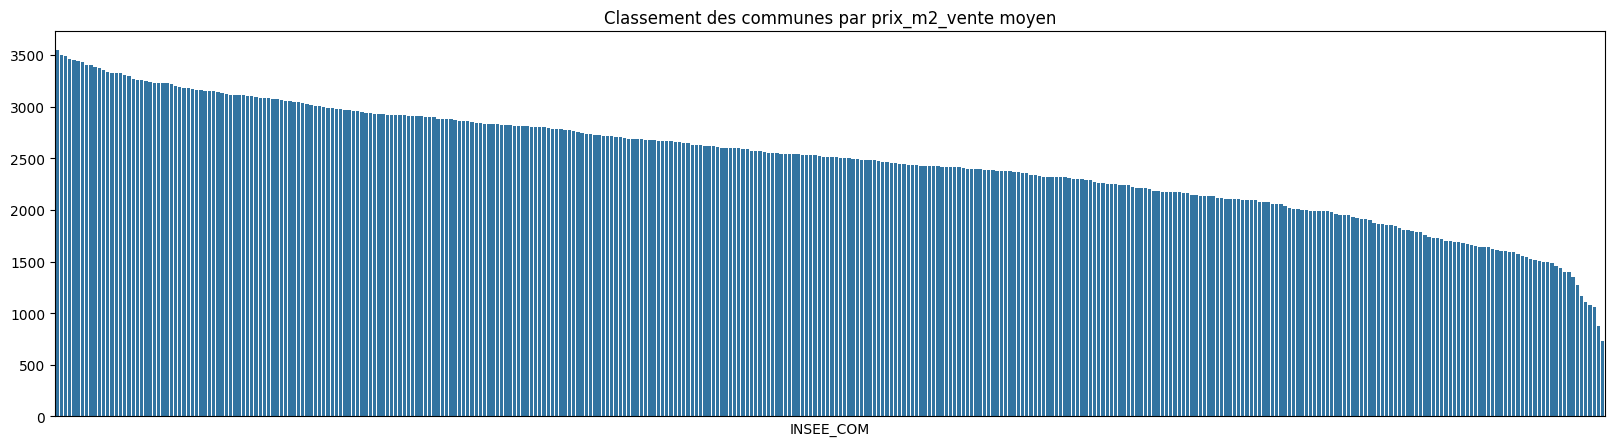

In [157]:
fig, ax = plt.subplots(figsize = (20,5))
top_com_prix_m2 = df_ventes_clean.groupby('INSEE_COM')['prix_m2_vente'].mean().sort_values(ascending=False)

sns.barplot(x=top_com_prix_m2.index, y=top_com_prix_m2.values, order=top_com_prix_m2.index)
plt.xticks([])
plt.title('Classement des communes par prix_m2_vente moyen');

Nous pouvons associer à chaque INSEE_COM, typedebien_lite et nb_pieces une moyenne prix_bien => puis standardiser cette valeur.

**Le Target Encoding (ou Mean Encoding) consiste à remplacer chaque modalité d'une variable catégorielle par la moyenne de la variable cible (y) associée à cette modalité. Ce type d'encodage est particulièrement utile pour les variables avec un grand nombre de catégories, là où le One-Hot Encoding peut devenir trop coûteux en mémoire.**

In [158]:
cols = ['INSEE_COM', 'typedebien_lite', 'nb_pieces']

mean_price_by_combo = (
    df_ventes_clean
    .groupby(cols, as_index=False)['prix_bien']
    .mean()
    .rename(columns={'prix_bien': 'prix_bien_target_encoding'})
)

df_ventes_clean = df_ventes_clean.merge(
    mean_price_by_combo,
    on=cols,
    how='left'
)

df_ventes_clean[['INSEE_COM', 'typedebien_lite', 'nb_pieces', 'prix_bien_target_encoding']]


,INSEE_COM,typedebien_lite,nb_pieces,prix_bien_target_encoding
0,68325,a,3,138500.000000
1,68044,m,4,216448.000000
2,68044,m,9,308950.000000
3,68044,a,4,118345.500000
4,68159,m,5,416488.888889
...,...,...,...,...
26919,68297,a,4,291217.120000
26920,68285,a,4,220779.500000
26921,68285,a,4,220779.500000
26922,68022,a,5,259479.333333


In [159]:
scaler_prix_bien_target_encoding = StandardScaler()
df_ventes_clean['prix_bien_target_encoding_scaled'] = scaler_prix_bien_target_encoding.fit_transform(df_ventes_clean[['prix_bien_target_encoding']])

df_ventes_clean[['INSEE_COM', 'typedebien_lite', 'nb_pieces', 'prix_bien_target_encoding', 'prix_bien_target_encoding_scaled']]

,INSEE_COM,typedebien_lite,nb_pieces,prix_bien_target_encoding,prix_bien_target_encoding_scaled
0,68325,a,3,138500.000000,-0.925188
1,68044,m,4,216448.000000,-0.370051
2,68044,m,9,308950.000000,0.288738
3,68044,a,4,118345.500000,-1.068726
4,68159,m,5,416488.888889,1.054618
...,...,...,...,...,...
26919,68297,a,4,291217.120000,0.162446
26920,68285,a,4,220779.500000,-0.339203
26921,68285,a,4,220779.500000,-0.339203
26922,68022,a,5,259479.333333,-0.063587


### OneHotEncoding

**Pour les variables catégorielles avec une faible cardinalité, nous allons utiliser le OneHotEncoding afin d'associer une valeur numérique à chaque cardinalité.**

#### Découverte des cardilanités

In [161]:
cat_cols = df_ventes_clean.select_dtypes(include=['object', 'category']).columns

cardinalites_df = (
    df_ventes_clean[cat_cols]
    .nunique(dropna=False)
    .reset_index()
    .rename(columns={'index': 'colonne', 0: 'cardinalite'})
)

print(cardinalites_df)


                colonne  cardinalite
0        type_annonceur            1
1            typedebien            5
2     typedetransaction            3
3                  dpeL           10
4     annonce_exclusive            3
5               parking            3
6                  cave            3
7            exposition           35
8             ges_class           10
9            videophone            3
10       porte_digicode            3
11            ascenseur            3
12    chauffage_energie           11
13    chauffage_systeme           14
14       chauffage_mode            7
15  categorie_annonceur            6
16        logement_neuf            3
17      typedebien_lite            3
18                 date           51
19           TYP_IRIS_x            3
20           TYP_IRIS_y            2


#### Gestion du champ date -> extraction de l'année

Le champ date a trop de cardinalité pour utiliser efficacement le OHE, nous allons extraire l'année de la date.

In [162]:
df_ventes_clean['date'] = pd.to_datetime(df_ventes_clean['date'])

df_ventes_clean['annee'] = df_ventes_clean['date'].dt.year

In [167]:
# Colonnes catégorielles (object ou category)
cat_cols = df_ventes_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.append('annee')

cardinalites_df = (
    df_ventes_clean[cat_cols]
    .nunique(dropna=False)
    .reset_index()
    .rename(columns={'index': 'colonne', 0: 'cardinalite'})
)

print(cardinalites_df)


                colonne  cardinalite
0        type_annonceur            1
1            typedebien            5
2     typedetransaction            3
3                  dpeL           10
4     annonce_exclusive            3
5               parking            3
6                  cave            3
7            exposition           35
8             ges_class           10
9            videophone            3
10       porte_digicode            3
11            ascenseur            3
12    chauffage_energie           11
13    chauffage_systeme           14
14       chauffage_mode            7
15  categorie_annonceur            6
16        logement_neuf            3
17      typedebien_lite            3
18           TYP_IRIS_x            3
19           TYP_IRIS_y            2
20                annee            5


In [168]:
df_ventes_clean['exposition'].value_counts()

exposition
0                       20838
Sud                      2164
Sud-Ouest                 646
Est                       612
Ouest                     505
Nord-Ouest                410
Sud-Est                   371
Est-Ouest                 360
sud-ouest                 198
Nord-Sud                  182
Sud-Est-Ouest             176
Nord                      141
Nord-Est                   98
sud-est                    82
traversant                 29
Nord Sud Est Ouest         15
Nord Est Ouest             13
nord,est                   11
Nord Sud Ouest             10
sud,est                     9
sud,ouest                   9
nord-est / sud-ouest        7
nord-ouest / sud-est        6
Nord Sud Est                6
Traversant-Est-Ouest        5
nord,ouest                  5
traversant nord-sud         4
sud est                     3
sud ouest                   2
SUD                         2
360°                        1
Nord-ouest                  1
SUD OUEST                   1

In [176]:
import re

df_ventes_clean['exposition_clean'] = (
    df_ventes_clean['exposition']
    .astype(str)          # au cas où il y ait des NaN ou autres types
    .str.lower()          # mise en minuscules
    .str.replace(r'[,/\\\-]', ' ', regex=True)   # remplace , / \ - par un espace
    .str.replace(r'\s+', ' ', regex=True)        # remplace multiples espaces par un seul
    .str.strip()                                  # supprime espaces en début/fin
)

In [177]:
df_ventes_clean['expo_nord']  = df_ventes_clean['exposition_clean'].str.contains(r'\bnord\b',  na=False).astype(int)
df_ventes_clean['expo_sud']   = df_ventes_clean['exposition_clean'].str.contains(r'\bsud\b',   na=False).astype(int)
df_ventes_clean['expo_est']   = df_ventes_clean['exposition_clean'].str.contains(r'\best\b',   na=False).astype(int)
df_ventes_clean['expo_ouest'] = df_ventes_clean['exposition_clean'].str.contains(r'\bouest\b', na=False).astype(int)

In [178]:
df_ventes_clean[['exposition', 'expo_nord', 'expo_sud', 'expo_est', 'expo_ouest']].head()

,exposition,expo_nord,expo_sud,expo_est,expo_ouest
0,0,0,0,0,0
1,Sud,0,1,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
